In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import pandas as pd
import gseapy as gp
import numpy as np
import matplotlib.pyplot as plt

from gseapy.scipalette import SciPalette

In [4]:
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = os.path.join(project_dir, "00_revisions/")
figure_dir = os.path.join(working_dir, "figures/")
data_dir = os.path.join(working_dir, "data/")

In [5]:
adata = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [6]:
adata.X = adata.layers["counts"].copy()

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

In [8]:
sc.tl.rank_genes_groups(
    adata,
    groupby="cycling_state_oren",
    use_raw=False,
    method="wilcoxon",
    groups=["Fast-cycling", "G0-arrested"],
    reference="Slow-cycling",
)

In [9]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
degs = pd.DataFrame(
    {
        group + "_" + key: result[key][group]
        for group in groups
        for key in ["names", "scores", "pvals", "pvals_adj", "logfoldchanges"]
    }
)

# Reactome PA

## Fast-cycling

In [10]:
pre_res = gp.prerank(
    degs.loc[:, ["Fast-cycling_names", "Fast-cycling_logfoldchanges"]],
    gene_sets="Reactome_Pathways_2024",
)

2025-10-24 15:15:59,430 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [11]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Mitotic Prometaphase,0.749624,2.625037,0.0,0.0,0.0,92/198,14.51%,BUB1;CENPA;PLK1;NCAPG;BUB1B;KNL1;NEK2;CENPE;NU...
1,prerank,Resolution of Sister Chromatid Cohesion,0.780408,2.566428,0.0,0.0,0.0,60/122,12.70%,BUB1;CENPA;PLK1;BUB1B;KNL1;CENPE;NUF2;CENPF;KI...
2,prerank,M Phase,0.691491,2.552235,0.0,0.0,0.0,125/357,15.04%,BUB1;CENPA;PLK1;NCAPG;BUB1B;KNL1;NEK2;KIF20A;C...
3,prerank,Cell Cycle Checkpoints,0.726822,2.549653,0.0,0.0,0.0,93/254,12.40%,BUB1;CENPA;PLK1;BUB1B;KNL1;GTSE1;CENPE;NUF2;CC...
4,prerank,Mitotic Spindle Checkpoint,0.799231,2.544745,0.0,0.0,0.0,39/110,5.71%,BUB1;CENPA;PLK1;BUB1B;KNL1;CENPE;NUF2;CENPF;KI...


In [13]:
degs_sig = degs.loc[degs["Fast-cycling_pvals_adj"] < 0.05]
fast_degs_up = degs_sig.loc[degs_sig["Fast-cycling_logfoldchanges"] > 0]
fast_degs_down = degs_sig.loc[degs_sig["Fast-cycling_logfoldchanges"] < 0]

In [14]:
fast_enr_up = gp.enrichr(fast_degs_up["Fast-cycling_names"], gene_sets="Reactome_Pathways_2024", outdir=None)

In [17]:
fast_enr_dw = gp.enrichr(fast_degs_down["Fast-cycling_names"], gene_sets="Reactome_Pathways_2024", outdir=None)

In [19]:
fast_enr_up.res2d["enrichment"] = "up"
fast_enr_dw.res2d["enrichment"] = "down"
fast_enr_res = pd.concat([fast_enr_up.res2d.head(), fast_enr_dw.res2d.head()])

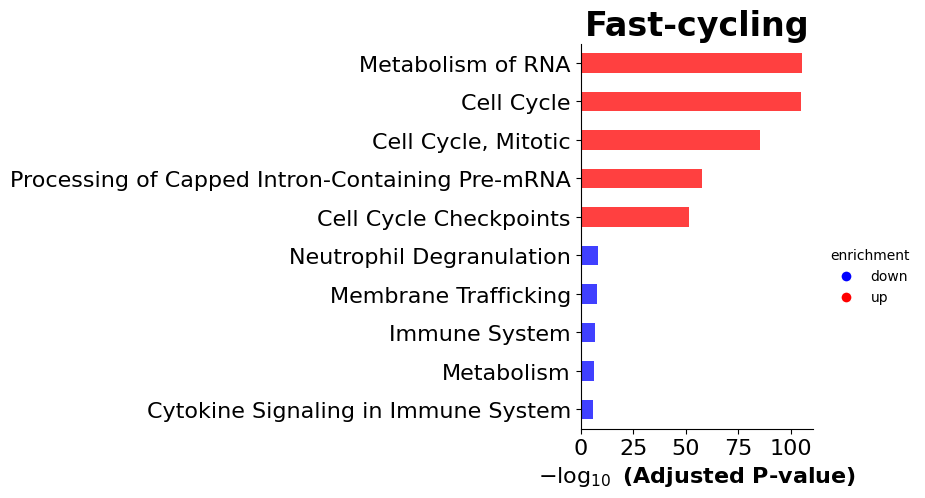

In [22]:
ax = gp.barplot(fast_enr_res, figsize=(3, 5), group="enrichment", title="Fast-cycling", color=["b", "r"])
plt.savefig(figure_dir + "fast_reactome.pdf", bbox_inches="tight")

## G0 arrested

In [23]:
pre_res = gp.prerank(
    degs.loc[:, ["G0-arrested_names", "G0-arrested_logfoldchanges"]],
    gene_sets="Reactome_Pathways_2024",
)

2025-10-24 15:17:05,029 [WARNING] Duplicated values found in preranked stats: 0.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [24]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Costimulation by the CD28 Family,0.661506,2.060664,0.0,0.002404,0.001,34/74,20.42%,TRAV19;TRBV12-3;TRAV29DV5;HLA-DRB5;HLA-DQA1;LY...
1,prerank,Phosphorylation of CD3 and TCR Zeta Chains,0.782408,2.043154,0.0,0.003005,0.003,23/27,19.36%,TRAV19;TRBV12-3;TRAV29DV5;HLA-DRB5;HLA-DQA1;HL...
2,prerank,Translocation of ZAP-70 to Immunological Synapse,0.801294,2.034714,0.0,0.002804,0.004,23/24,19.36%,TRAV19;TRBV12-3;TRAV29DV5;HLA-DRB5;HLA-DQA1;HL...
3,prerank,Generation of Second Messenger Molecules,0.724971,2.029792,0.0,0.002103,0.004,29/39,21.39%,TRAV19;TRBV12-3;TRAV29DV5;HLA-DRB5;HLA-DQA1;FY...
4,prerank,Interferon Gamma Signaling,0.628322,2.022119,0.0,0.001683,0.004,57/93,24.99%,GBP6;GBP1;HLA-DRB5;OASL;GBP4;TRIM31;HLA-DQA1;V...


In [26]:
degs_sig = degs.loc[degs["G0-arrested_pvals_adj"] < 0.05]
g0_degs_up = degs_sig.loc[degs_sig["G0-arrested_logfoldchanges"] > 0]
g0_degs_down = degs_sig.loc[degs_sig["G0-arrested_logfoldchanges"] < 0]

In [27]:
g0_enr_up = gp.enrichr(g0_degs_up["G0-arrested_names"], gene_sets="Reactome_Pathways_2024", outdir=None)

In [30]:
g0_enr_dw = gp.enrichr(g0_degs_down["G0-arrested_names"], gene_sets="Reactome_Pathways_2024", outdir=None)

In [32]:
g0_enr_up.res2d["enrichment"] = "up"
g0_enr_dw.res2d["enrichment"] = "down"
g0_enr_res = pd.concat([g0_enr_up.res2d.head(), g0_enr_dw.res2d.head()])

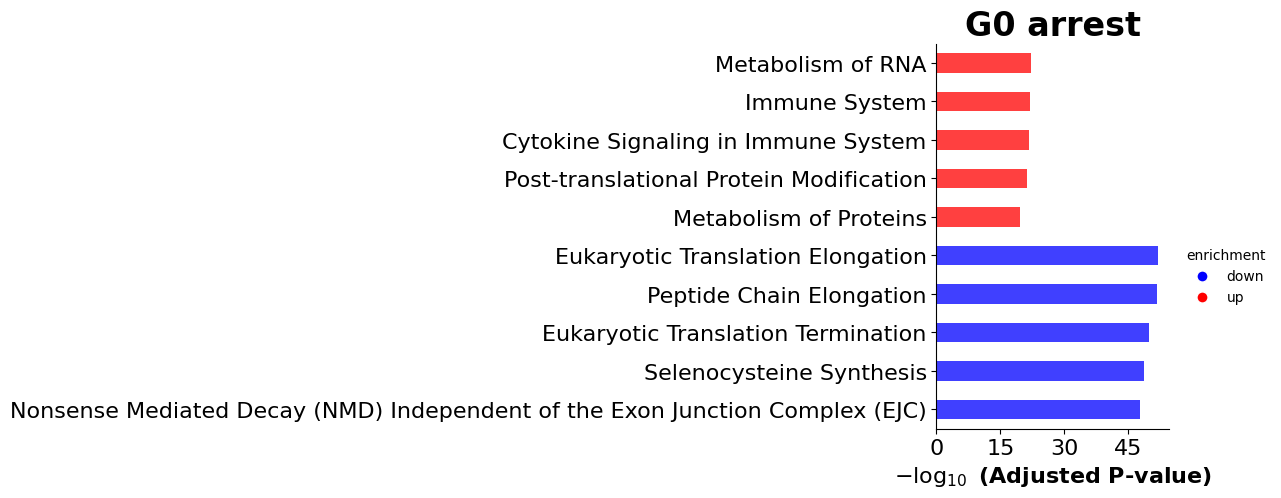

In [34]:
ax = gp.barplot(g0_enr_res, figsize=(3, 5), group="enrichment", title="G0 arrest", color=["b", "r"])
plt.savefig(os.path.join(figure_dir, "g0_reactome.pdf"), bbox_inches="tight")